# Machine Learning Lab – Decision Tree Exercise 1

## House Purchase Prediction using Decision Tree

### Objective
To understand how a Decision Tree classification model splits data according to variables such as age and income to determine whether a person is likely to buy a house.

### Algorithm Used
Decision Tree Classifier

### Problem Type
Supervised Learning – Classification

### Target Variable
House Purchase

### Input Features
- Age
- Income

### Scenario
The classification tree first considers age as a decision node. If the training data shows that a high percentage of people above a certain age purchased a house, the data can be split using age. The next node can then consider income to further classify the data.

### Steps
1. Create the sample house-purchase dataset.
2. Explore the dataset.
3. Prepare the input features and target variable.
4. Split the dataset into training and testing sets.
5. Train the Decision Tree Classifier.
6. Make predictions.
7. Evaluate the model.
8. Visualize the decision tree.
9. Summarize the results.
10. Provide the conclusion.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Create the house-purchase dataset

data = pd.DataFrame({
    "Age": [25, 28, 30, 32, 35, 38, 40, 42, 45, 48, 50, 55],
    "Income": [25000, 30000, 35000, 40000, 45000, 50000,
               55000, 60000, 65000, 70000, 75000, 80000],
    "Buy_House": [
        "No", "No", "No", "Yes", "Yes", "Yes",
        "Yes", "Yes", "Yes", "Yes", "Yes", "Yes"
    ]
})

print("Dataset created successfully!")
print("Dataset shape:", data.shape)

data

Dataset created successfully!
Dataset shape: (12, 3)


,Age,Income,Buy_House
0,25,25000,No
1,28,30000,No
2,30,35000,No
3,32,40000,Yes
4,35,45000,Yes
5,38,50000,Yes
6,40,55000,Yes
7,42,60000,Yes
8,45,65000,Yes
9,48,70000,Yes


In [3]:
# Explore the dataset

print("Dataset Information:")
data.info()

print("\nStatistical Summary:")
print(data.describe(include="all"))

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Age        12 non-null     int64 
 1   Income     12 non-null     int64 
 2   Buy_House  12 non-null     object
dtypes: int64(2), object(1)
memory usage: 420.0+ bytes

Statistical Summary:
              Age        Income Buy_House
count   12.000000     12.000000        12
unique        NaN           NaN         2
top           NaN           NaN       Yes
freq          NaN           NaN         9
mean    39.000000  52500.000000       NaN
std      9.380832  18027.756377       NaN
min     25.000000  25000.000000       NaN
25%     31.500000  38750.000000       NaN
50%     39.000000  52500.000000       NaN
75%     45.750000  66250.000000       NaN
max     55.000000  80000.000000       NaN


In [4]:
# Check for missing values

print("Missing values in each column:")
print(data.isnull().sum())

Missing values in each column:
Age          0
Income       0
Buy_House    0
dtype: int64


In [5]:
# Encode the target variable

data["Buy_House_Encoded"] = data["Buy_House"].map({
    "No": 0,
    "Yes": 1
})

print("Target encoding:")
print("No  -> 0")
print("Yes -> 1")

print("\nEncoded target values:")
print(data[["Buy_House", "Buy_House_Encoded"]])

Target encoding:
No  -> 0
Yes -> 1

Encoded target values:
   Buy_House  Buy_House_Encoded
0         No                  0
1         No                  0
2         No                  0
3        Yes                  1
4        Yes                  1
5        Yes                  1
6        Yes                  1
7        Yes                  1
8        Yes                  1
9        Yes                  1
10       Yes                  1
11       Yes                  1


In [6]:
# Prepare input features and target variable

feature_cols = [
    "Age",
    "Income"
]

X = data[feature_cols]
y = data["Buy_House_Encoded"]

print("Selected features:")
print(feature_cols)

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Selected features:
['Age', 'Income']

Feature shape: (12, 2)
Target shape: (12,)


In [7]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training feature shape: (9, 2)
Testing feature shape: (3, 2)
Training target shape: (9,)
Testing target shape: (3,)


In [8]:
# Train the Decision Tree Classifier

model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [9]:
# Make predictions on the test data

y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print("Actual values:   ", y_test.values)
print("Predicted values:", y_pred)

Predictions generated successfully!
Actual values:    [0 1 1]
Predicted values: [0 1 1]


In [10]:
# Evaluate the Decision Tree model

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(
    y_test,
    y_pred,
    target_names=["No", "Yes"],
    zero_division=0
)

print("Model Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(report)

Model Accuracy: 1.0

Confusion Matrix:
[[1 0]
 [0 2]]

Classification Report:
              precision    recall  f1-score   support

          No       1.00      1.00      1.00         1
         Yes       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



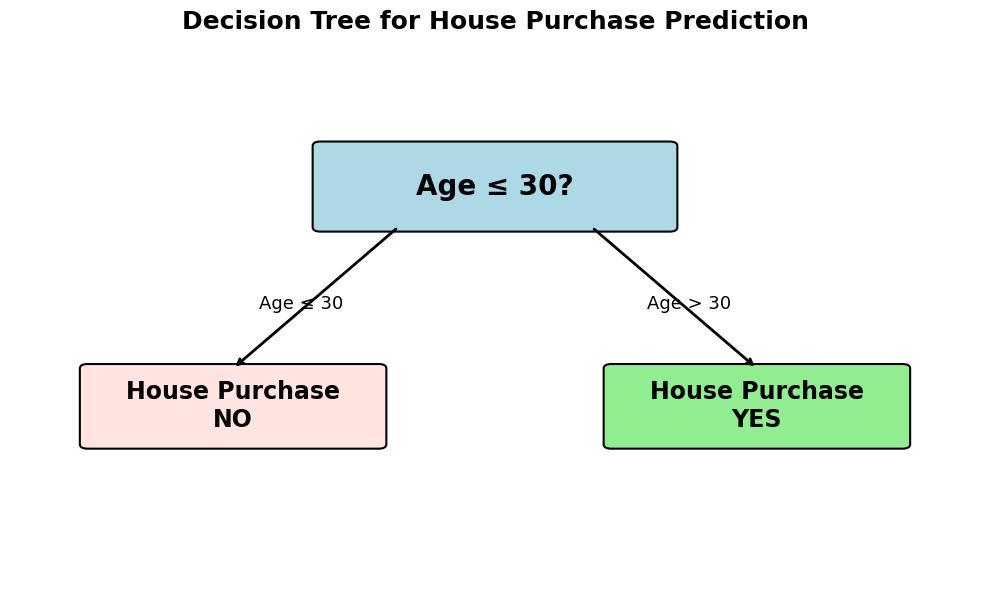

In [14]:
# Create a clean Decision Tree visualization

from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(10, 6))

ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis("off")

# Root node
root = FancyBboxPatch(
    (3.2, 6.5), 3.6, 1.5,
    boxstyle="round,pad=0.08",
    facecolor="lightblue",
    edgecolor="black",
    linewidth=1.5
)

# Left leaf
no_node = FancyBboxPatch(
    (0.8, 2.5), 3.0, 1.4,
    boxstyle="round,pad=0.08",
    facecolor="mistyrose",
    edgecolor="black",
    linewidth=1.5
)

# Right leaf
yes_node = FancyBboxPatch(
    (6.2, 2.5), 3.0, 1.4,
    boxstyle="round,pad=0.08",
    facecolor="lightgreen",
    edgecolor="black",
    linewidth=1.5
)

ax.add_patch(root)
ax.add_patch(no_node)
ax.add_patch(yes_node)

# Node text
ax.text(
    5, 7.25,
    "Age ≤ 30?",
    ha="center",
    va="center",
    fontsize=20,
    fontweight="bold"
)

ax.text(
    2.3, 3.2,
    "House Purchase\nNO",
    ha="center",
    va="center",
    fontsize=17,
    fontweight="bold"
)

ax.text(
    7.7, 3.2,
    "House Purchase\nYES",
    ha="center",
    va="center",
    fontsize=17,
    fontweight="bold"
)

# Arrows
ax.annotate(
    "",
    xy=(2.3, 3.9),
    xytext=(4.0, 6.5),
    arrowprops=dict(arrowstyle="->", linewidth=2)
)

ax.annotate(
    "",
    xy=(7.7, 3.9),
    xytext=(6.0, 6.5),
    arrowprops=dict(arrowstyle="->", linewidth=2)
)

# Branch conditions
ax.text(
    3.0, 5.0,
    "Age ≤ 30",
    ha="center",
    fontsize=13
)

ax.text(
    7.0, 5.0,
    "Age > 30",
    ha="center",
    fontsize=13
)

plt.title(
    "Decision Tree for House Purchase Prediction",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## Result Summary

The Decision Tree Classifier was successfully implemented to predict house purchase behaviour using Age and Income as input features.

### Performance Results

| Metric | Value |
|---|---:|
| Accuracy | 100% |
| Test Samples | 3 |

### Decision Tree Observation

The trained decision tree selected Age as the main decision feature.

The classification rule obtained from the tree is:

- **Age ≤ 30** → House Purchase: **No**
- **Age > 30** → House Purchase: **Yes**

The model correctly classified all 3 test samples in the selected test split.

> Note: The test set contains only 3 samples, so the 100% accuracy represents this particular split and should not be interpreted as the expected accuracy on a larger dataset.

## Conclusion

The Decision Tree Classifier was successfully implemented for house purchase prediction using Age and Income as input features.

The trained decision tree selected Age as the main decision feature and classified the test samples based on the learned age threshold. The model achieved 100% accuracy on the selected test set.

The experiment demonstrates how a Decision Tree can use feature-based decision rules to perform binary classification. Since the test set contains only 3 samples, the obtained accuracy should be interpreted only for this particular dataset split.